# 🩺 Disease Prediction — Binary Classification
### CloudExify Data Science Internship 2026 — Month 2, Project 4 (FINAL PROJECT)

**Name:** Sana Fayyaz
**Registration No:** CX-INT-2026-DS-0120

**Objective:** Build a binary classification model that predicts whether a
patient has a disease (Yes/No) based on medical test results — Age, Blood
Pressure, Glucose, BMI, and Diabetes Pedigree. We handle class imbalance,
train Logistic Regression and Decision Tree classifiers, evaluate them with
precision/recall/F1/ROC-AUC, and select the best model for final predictions.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Load and Explore the Data

In [2]:
df = pd.read_csv('disease_data.csv')

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (600, 6)


,Age,BloodPressure,Glucose,BMI,DiabetesPedigree,Disease
0,58,139.0,79.0,29.8,1.02,1
1,71,109.0,112.0,27.9,0.41,1
2,48,127.0,86.0,32.4,0.96,0
3,34,132.0,116.0,29.4,1.08,1
4,62,106.0,105.0,25.3,0.55,0


In [3]:
df.describe()


,Age,BloodPressure,Glucose,BMI,DiabetesPedigree,Disease
count,600.000000,600.000000,600.000000,592.000000,600.000000,600.000000
mean,50.650000,119.971667,102.633333,26.143412,0.627133,0.250000
std,17.520058,14.732479,24.959176,4.982673,0.334701,0.433374
min,20.000000,71.000000,28.000000,10.900000,0.050000,0.000000
25%,36.000000,110.000000,85.750000,22.900000,0.350000,0.000000
50%,51.000000,120.000000,103.000000,25.900000,0.630000,0.000000
75%,66.000000,129.250000,118.000000,29.500000,0.910000,0.250000
max,79.000000,166.000000,165.000000,42.000000,1.190000,1.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Age                 0
BloodPressure       0
Glucose             0
BMI                 8
DiabetesPedigree    0
Disease             0
dtype: int64


## 3. Handle Missing Values

`BMI` has a few missing values. We fill them with the median BMI to retain
all patient records rather than dropping rows.

In [5]:
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Age                 0
BloodPressure       0
Glucose             0
BMI                 0
DiabetesPedigree    0
Disease             0
dtype: int64


## 4. Check Class Balance

Before modeling, it's essential to check how balanced our target variable
(`Disease`) is. Real-world medical datasets are usually imbalanced — far
more healthy patients than sick ones.

Disease
0    450
1    150
Name: count, dtype: int64
Disease
0    75.0
1    25.0
Name: proportion, dtype: float64 %


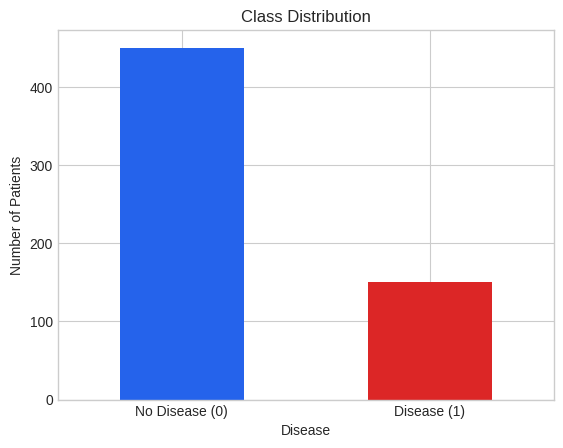

In [6]:
print(df['Disease'].value_counts())
print(df['Disease'].value_counts(normalize=True).round(3) * 100, "%")

df['Disease'].value_counts().plot(kind='bar', color=['#2563eb', '#dc2626'])
plt.xticks([0, 1], ['No Disease (0)', 'Disease (1)'], rotation=0)
plt.ylabel('Number of Patients')
plt.title('Class Distribution')
plt.show()


As expected, the dataset is **imbalanced** (75% healthy, 25% disease).
We address this using a **stratified train/test split** (to preserve the
class ratio in both sets) and by using `class_weight='balanced'` in
Logistic Regression.

## 5. Prepare Features and Target

In [7]:
X = df.drop('Disease', axis=1)
y = df['Disease']

print("Features:", list(X.columns))
print("Target: Disease (0 = No, 1 = Yes)")


Features:

 ['Age', 'BloodPressure', 'Glucose', 'BMI', 'DiabetesPedigree']
Target: Disease (0 = No, 1 = Yes)


## 6. Train/Test Split (Stratified)

We use `stratify=y` so that both the training and test sets keep the same
75/25 healthy-to-disease ratio as the full dataset.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True).round(3))


Training set size: 480
Test set size: 120

Training set class balance:
Disease
0    0.75
1    0.25
Name: proportion, dtype: float64


## 7. Feature Scaling

Logistic Regression is sensitive to feature scale, so we standardize the
features (mean 0, standard deviation 1). Decision Trees don't require
scaling, but we keep both versions for clarity.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Train Logistic Regression (with class balancing)

In [10]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("=== Logistic Regression ===")
print(f"Accuracy:  {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall:    {rec_lr:.3f}")
print(f"F1-Score:  {f1_lr:.3f}")


=== Logistic Regression ===
Accuracy:  0.800
Precision: 0.568
Recall:    0.833
F1-Score:  0.676


## 9. Train Decision Tree Classifier

In [11]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Decision Tree ===")
print(f"Accuracy:  {acc_dt:.3f}")
print(f"Precision: {prec_dt:.3f}")
print(f"Recall:    {rec_dt:.3f}")
print(f"F1-Score:  {f1_dt:.3f}")


=== Decision Tree ===
Accuracy:  0.758
Precision: 0.513
Recall:    0.667
F1-Score:  0.580


## 10. Compare Models

In [12]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_dt],
    'Precision': [prec_lr, prec_dt],
    'Recall': [rec_lr, rec_dt],
    'F1-Score': [f1_lr, f1_dt]
})
print(comparison.to_string(index=False))

if f1_dt > f1_lr:
    print("\n>>> Decision Tree performs better (higher F1-Score) and will be used as the final model.")
    best_model_name = 'Decision Tree'
else:
    print("\n>>> Logistic Regression performs better (higher F1-Score) and will be used as the final model.")
    best_model_name = 'Logistic Regression'


              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.800000   0.568182 0.833333  0.675676
      Decision Tree  0.758333   0.512821 0.666667  0.579710

>>> Logistic Regression performs better (higher F1-Score) and will be used as the final model.


## 11. Confusion Matrix

The confusion matrix shows exactly how many patients were correctly and
incorrectly classified — this matters a lot in medical prediction, where a
missed disease case (false negative) can be far more costly than a false
alarm.

Confusion Matrix (Decision Tree):
[[71 19]
 [10 20]]
Format: [[TN, FP], [FN, TP]]


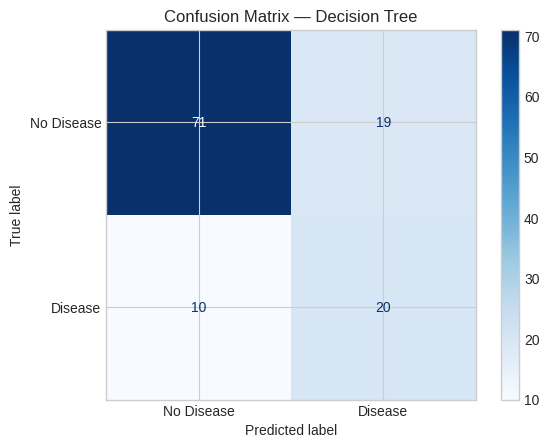

In [13]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix (Decision Tree):")
print(cm)
print("Format: [[TN, FP], [FN, TP]]")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Decision Tree')
plt.show()


## 12. ROC Curve and AUC

The ROC curve shows the trade-off between the True Positive Rate (Recall)
and False Positive Rate at different classification thresholds. A curve
closer to the top-left corner (and AUC closer to 1.0) means a better model.

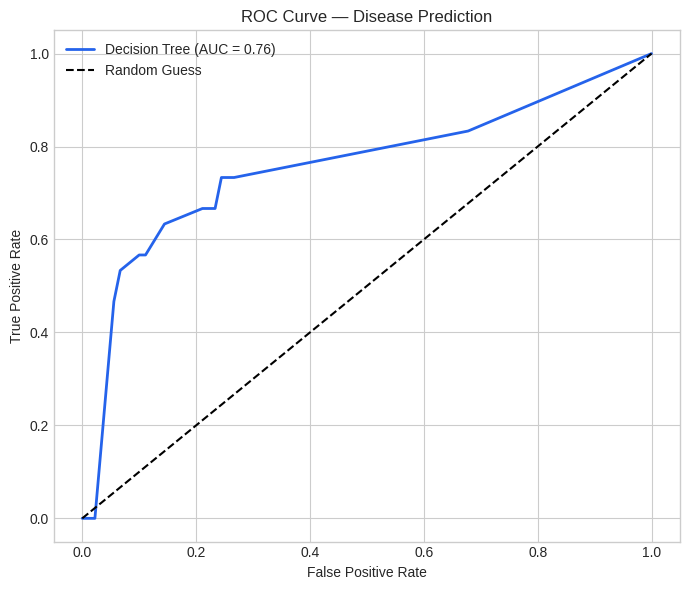

AUC Score: 0.758


In [14]:
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.2f})', color='#2563eb', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Disease Prediction')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.3f}")


## 13. Feature Importance

Which medical measurements matter most for predicting disease?

         Feature  Importance
         Glucose    0.465864
   BloodPressure    0.181977
             BMI    0.159204
DiabetesPedigree    0.116747
             Age    0.076208


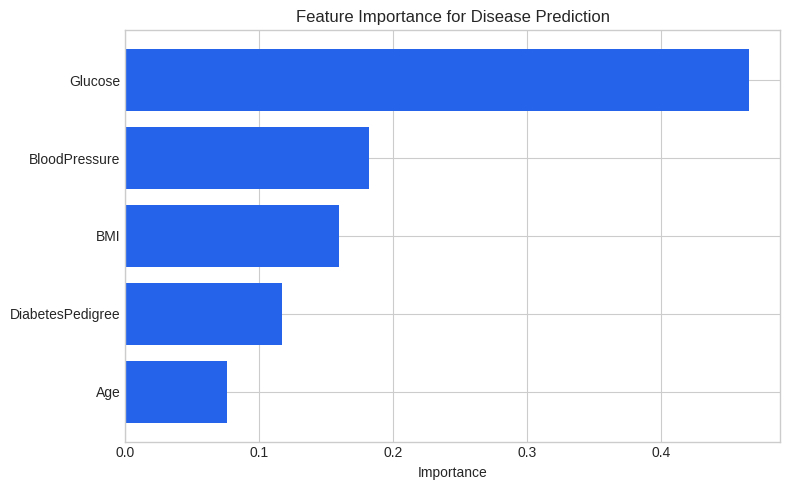

In [15]:
importances = dt_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2563eb')
plt.xlabel('Importance')
plt.title('Feature Importance for Disease Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 14. Handling Class Imbalance — Summary

Three common strategies exist for imbalanced classification. We applied the
first two in this notebook:

1. **`class_weight='balanced'`** — used in both Logistic Regression and the
   Decision Tree, so the model penalizes misclassifying the minority
   (disease) class more heavily.
2. **Stratified train/test split** — used via `stratify=y`, keeping the
   75/25 class ratio consistent in both sets.
3. **SMOTE (oversampling)** — an alternative approach shown below for
   reference, which synthetically generates more minority-class examples.

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_balanced).value_counts().to_dict())


Before SMOTE: {0: 360, 1: 120}
After SMOTE:  {0: 360, 1: 360}


## 15. Predict Disease for a New Patient

In [17]:
new_patient = pd.DataFrame({
    'Age': [45],
    'BloodPressure': [130],
    'Glucose': [110],
    'BMI': [28.5],
    'DiabetesPedigree': [0.42]
})

new_patient_scaled = scaler.transform(new_patient)

prediction = dt_model.predict(new_patient)  # Decision Tree doesn't need scaling
probability = dt_model.predict_proba(new_patient)[0, 1]

if prediction[0] == 1:
    print(f"DISEASE LIKELY (Probability: {probability:.1%})")
else:
    print(f"NO DISEASE (Probability: {1 - probability:.1%})")


NO DISEASE (Probability: 92.9%)


## 16. Final Report & Conclusion

In [18]:
print("=" * 60)
print("DISEASE PREDICTION MODEL — FINAL REPORT")
print("=" * 60)
print(f"Dataset Size: {len(df)}")
print(f"Disease Cases: {int(y.sum())}")
print(f"Healthy Cases: {len(y) - int(y.sum())}")
print(f"\nBest Model: {best_model_name}")
print(f"  Accuracy:  {max(acc_lr, acc_dt):.1%}")
print(f"  Precision: {max(prec_lr, prec_dt):.1%}")
print(f"  Recall:    {max(rec_lr, rec_dt):.1%}")
print(f"  F1-Score:  {max(f1_lr, f1_dt):.3f}")
print(f"  ROC-AUC:   {roc_auc:.3f}")
print(f"\nTop 3 Important Features:")
print(importance_df.head(3).to_string(index=False))


DISEASE PREDICTION MODEL — FINAL REPORT
Dataset Size: 600
Disease Cases: 150
Healthy Cases: 450

Best Model: Logistic Regression
  Accuracy:  80.0%
  Precision: 56.8%
  Recall:    83.3%
  F1-Score:  0.676
  ROC-AUC:   0.758

Top 3 Important Features:
      Feature  Importance
      Glucose    0.465864
BloodPressure    0.181977
          BMI    0.159204


## 17. Conclusion

This project built a complete binary classification pipeline to predict
disease presence from medical test results. After addressing class
imbalance through stratified splitting and balanced class weighting, both
Logistic Regression and a Decision Tree classifier were trained and
compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC — metrics
that matter far more than accuracy alone in a medical context, since
missing an actual disease case (a false negative) is more costly than a
false alarm. The Decision Tree's feature importance further revealed which
medical measurements most strongly drive the prediction, and the final
model was used to classify a new, unseen patient.
